<a href="https://colab.research.google.com/github/Akshat2512/Crime-Prediction/blob/master/Crime_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
data = pd.read_csv("https://data.cityofnewyork.us/resource/5uac-w243.csv?$limit=900000&$where=cmplnt_fr_dt%20between%20'2001-01-01T00:00:00'%20and%20'2024-12-31T23:00:00'&$order=cmplnt_fr_dt%20ASC")
# data = pd.read_csv("https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=90000000&$where=date%20between%20'2001-01-01T00:00:00'%20and%20'2024-12-31T23:00:00'&$order=date%20ASC")

In [ ]:
data.tail(200)

,cmplnt_num,addr_pct_cd,boro_nm,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,crm_atpt_cptd_cd,hadevelopt,housing_psa,...,transit_district,vic_age_group,vic_race,vic_sex,x_coord_cd,y_coord_cd,latitude,longitude,lat_lon,geocoded_column
554781,279757897,110.0,QUEENS,2023-12-31T00:00:00.000,17:17:00,2023-12-31T00:00:00.000,17:50:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,D,1019946.0,206619.0,40.733729,-73.871197,"(40.733729, -73.871197)",POINT (-73.871197 40.733729)
554782,279733492,49.0,BRONX,2023-12-31T00:00:00.000,00:05:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1019697.0,250444.0,40.854015,-73.871866,"(40.85401464106379, -73.87186603367385)",POINT (-73.87186603367385 40.85401464106379)
554783,279761667,52.0,BRONX,2023-12-31T00:00:00.000,10:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,45-64,WHITE,M,1019732.0,259272.0,40.878246,-73.871692,"(40.878246, -73.871692)",POINT (-73.871692 40.878246)
554784,279740811,115.0,QUEENS,2023-12-31T00:00:00.000,03:45:00,2023-12-31T00:00:00.000,03:55:00,COMPLETED,(null),NaN,...,NaN,25-44,WHITE HISPANIC,M,1018696.0,216005.0,40.759494,-73.875659,"(40.759494, -73.875659)",POINT (-73.875659 40.759494)
554785,279743139,75.0,BROOKLYN,2023-12-31T00:00:00.000,00:40:00,2023-12-31T00:00:00.000,00:42:00,COMPLETED,(null),NaN,...,NaN,18-24,ASIAN / PACIFIC ISLANDER,M,1019154.0,184293.0,40.672450,-73.874172,"(40.67245, -73.874172)",POINT (-73.874172 40.67245)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554976,279766994,105.0,QUEENS,2023-12-31T00:00:00.000,21:20:00,2023-12-31T00:00:00.000,21:20:00,COMPLETED,(null),NaN,...,NaN,18-24,BLACK,M,1055498.0,197111.0,40.707416,-73.743018,"(40.707416, -73.743018)",POINT (-73.743018 40.707416)
554977,279767324,105.0,QUEENS,2023-12-31T00:00:00.000,18:50:00,2023-12-31T00:00:00.000,19:00:00,COMPLETED,(null),NaN,...,NaN,45-64,BLACK,M,1058377.0,200237.0,40.715972,-73.732598,"(40.715972, -73.732598)",POINT (-73.732598 40.715972)
554978,279763418,105.0,QUEENS,2023-12-31T00:00:00.000,21:40:00,2023-12-31T00:00:00.000,21:50:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,M,1057470.0,182762.0,40.668013,-73.736062,"(40.668013394907824, -73.73606181904873)",POINT (-73.73606181904873 40.668013394907824)
554979,279766995,105.0,QUEENS,2023-12-31T00:00:00.000,18:35:00,2023-12-31T00:00:00.000,18:43:00,COMPLETED,(null),NaN,...,NaN,18-24,BLACK,F,1056692.0,191467.0,40.691915,-73.738771,"(40.691915, -73.738771)",POINT (-73.738771 40.691915)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554981 entries, 0 to 554980
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cmplnt_num         554981 non-null  object 
 1   addr_pct_cd        554912 non-null  float64
 2   boro_nm            554981 non-null  object 
 3   cmplnt_fr_dt       554981 non-null  object 
 4   cmplnt_fr_tm       554981 non-null  object 
 5   cmplnt_to_dt       520261 non-null  object 
 6   cmplnt_to_tm       554981 non-null  object 
 7   crm_atpt_cptd_cd   554981 non-null  object 
 8   hadevelopt         554981 non-null  object 
 9   housing_psa        36014 non-null   float64
 10  jurisdiction_code  554981 non-null  int64  
 11  juris_desc         554981 non-null  object 
 12  ky_cd              554981 non-null  int64  
 13  law_cat_cd         554981 non-null  object 
 14  loc_of_occur_desc  554981 non-null  object 
 15  ofns_desc          554981 non-null  object 
 16  pa

In [ ]:
data.isnull().sum()

cmplnt_num                0
addr_pct_cd              69
boro_nm                   0
cmplnt_fr_dt              0
cmplnt_fr_tm              0
cmplnt_to_dt          34720
cmplnt_to_tm              0
crm_atpt_cptd_cd          0
hadevelopt                0
housing_psa          518967
jurisdiction_code         0
juris_desc                0
ky_cd                     0
law_cat_cd                0
loc_of_occur_desc         0
ofns_desc                 0
parks_nm                  0
patrol_boro               0
pd_cd                   381
pd_desc                   0
prem_typ_desc             0
rpt_dt                    0
station_name              0
susp_age_group            0
susp_race                 0
susp_sex                  0
transit_district     540248
vic_age_group             0
vic_race                  0
vic_sex                   0
x_coord_cd               12
y_coord_cd               12
latitude                 12
longitude                12
lat_lon                  12
geocoded_column     

In [ ]:
#new york
df = data[['cmplnt_num','cmplnt_fr_dt','cmplnt_fr_tm','rpt_dt','ofns_desc','prem_typ_desc','boro_nm','vic_sex', 'susp_sex', 'latitude', 'longitude']]
df
#chicago
# df = data[['id','date','primary_type','location_description','block','district','arrest','domestic', 'latitude', 'longitude']]
# df

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,rpt_dt,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude
0,276064587,2001-02-20T00:00:00.000,10:00:00,2023-10-17T00:00:00.000,FORGERY,(null),BROOKLYN,F,(null),40.654074,-73.926256
1,270189205,2001-04-01T00:00:00.000,00:00:00,2023-06-21T00:00:00.000,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE - APT. HOUSE,BROOKLYN,F,U,40.663036,-73.952339
2,261406434,2001-04-21T00:00:00.000,16:35:00,2023-01-03T00:00:00.000,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,BRONX,M,M,40.893211,-73.859176
3,267991366,2001-05-01T00:00:00.000,06:00:00,2023-05-09T00:00:00.000,RAPE,RESIDENCE-HOUSE,QUEENS,F,M,40.682398,-73.840072
4,267676735,2001-06-01T00:00:00.000,15:00:00,2023-05-03T00:00:00.000,SEX CRIMES,RESIDENCE - APT. HOUSE,BROOKLYN,M,M,40.664121,-73.947765
...,...,...,...,...,...,...,...,...,...,...,...
554976,279766994,2023-12-31T00:00:00.000,21:20:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018
554977,279767324,2023-12-31T00:00:00.000,18:50:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598
554978,279763418,2023-12-31T00:00:00.000,21:40:00,2023-12-31T00:00:00.000,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062
554979,279766995,2023-12-31T00:00:00.000,18:35:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,F,F,40.691915,-73.738771


In [ ]:
df_year = df[df['block']=='045XX N CENTRAL PARK AVE']
df_year

KeyError: 'block'

In [ ]:
df.isnull().sum()

cmplnt_num        0
cmplnt_fr_dt      0
cmplnt_fr_tm      0
rpt_dt            0
ofns_desc         0
prem_typ_desc     0
boro_nm           0
vic_sex           0
susp_sex          0
latitude         12
longitude        12
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df.to_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_crime_2001_2023.csv', index=False)

In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_crime_2001_2023.csv')

In [ ]:
df.isnull().sum()

cmplnt_num       0
cmplnt_fr_dt     0
cmplnt_fr_tm     0
rpt_dt           0
ofns_desc        0
prem_typ_desc    0
boro_nm          0
vic_sex          0
susp_sex         0
latitude         0
longitude        0
dtype: int64

In [ ]:
df[(df['latitude'].isnull())]

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,rpt_dt,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude


In [ ]:
df_year = df.copy()

In [ ]:
df_year

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,rpt_dt,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude
0,276064587,2001-02-20T00:00:00.000,10:00:00,2023-10-17T00:00:00.000,FORGERY,(null),BROOKLYN,F,(null),40.654074,-73.926256
1,270189205,2001-04-01T00:00:00.000,00:00:00,2023-06-21T00:00:00.000,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE - APT. HOUSE,BROOKLYN,F,U,40.663036,-73.952339
2,261406434,2001-04-21T00:00:00.000,16:35:00,2023-01-03T00:00:00.000,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,BRONX,M,M,40.893211,-73.859176
3,267991366,2001-05-01T00:00:00.000,06:00:00,2023-05-09T00:00:00.000,RAPE,RESIDENCE-HOUSE,QUEENS,F,M,40.682398,-73.840072
4,267676735,2001-06-01T00:00:00.000,15:00:00,2023-05-03T00:00:00.000,SEX CRIMES,RESIDENCE - APT. HOUSE,BROOKLYN,M,M,40.664121,-73.947765
...,...,...,...,...,...,...,...,...,...,...,...
554964,279766994,2023-12-31T00:00:00.000,21:20:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018
554965,279767324,2023-12-31T00:00:00.000,18:50:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598
554966,279763418,2023-12-31T00:00:00.000,21:40:00,2023-12-31T00:00:00.000,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062
554967,279766995,2023-12-31T00:00:00.000,18:35:00,2023-12-31T00:00:00.000,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,F,F,40.691915,-73.738771


In [ ]:
df_year.cmplnt_fr_dt =  pd.to_datetime(df_year.cmplnt_fr_dt,format = 'ISO8601')
df_year.cmplnt_fr_tm =  pd.to_datetime(df_year.cmplnt_fr_tm,format = '%H:%M:%S')
df_year.rpt_dt =  pd.to_datetime(df_year.rpt_dt,format = 'ISO8601')
df_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554969 entries, 0 to 554968
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cmplnt_num     554969 non-null  object        
 1   cmplnt_fr_dt   554969 non-null  datetime64[ns]
 2   cmplnt_fr_tm   554969 non-null  datetime64[ns]
 3   rpt_dt         554969 non-null  datetime64[ns]
 4   ofns_desc      554969 non-null  object        
 5   prem_typ_desc  554969 non-null  object        
 6   boro_nm        554969 non-null  object        
 7   vic_sex        554969 non-null  object        
 8   susp_sex       554969 non-null  object        
 9   latitude       554969 non-null  float64       
 10  longitude      554969 non-null  float64       
dtypes: datetime64[ns](3), float64(2), object(6)
memory usage: 46.6+ MB


In [ ]:

T=pd.DataFrame(df_year['cmplnt_fr_tm'].dt.strftime('%H:%M:%S'))
D=pd.DataFrame(df_year['cmplnt_fr_dt'].dt.strftime('%Y-%m-%d'))
df_year['date'] = D['cmplnt_fr_dt']+'T'+T['cmplnt_fr_tm']

In [ ]:
df_year

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,rpt_dt,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude,date
0,276064587,2001-02-20,1900-01-01 10:00:00,2023-10-17,FORGERY,(null),BROOKLYN,F,(null),40.654074,-73.926256,2001-02-20T10:00:00
1,270189205,2001-04-01,1900-01-01 00:00:00,2023-06-21,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE - APT. HOUSE,BROOKLYN,F,U,40.663036,-73.952339,2001-04-01T00:00:00
2,261406434,2001-04-21,1900-01-01 16:35:00,2023-01-03,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,BRONX,M,M,40.893211,-73.859176,2001-04-21T16:35:00
3,267991366,2001-05-01,1900-01-01 06:00:00,2023-05-09,RAPE,RESIDENCE-HOUSE,QUEENS,F,M,40.682398,-73.840072,2001-05-01T06:00:00
4,267676735,2001-06-01,1900-01-01 15:00:00,2023-05-03,SEX CRIMES,RESIDENCE - APT. HOUSE,BROOKLYN,M,M,40.664121,-73.947765,2001-06-01T15:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
554964,279766994,2023-12-31,1900-01-01 21:20:00,2023-12-31,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018,2023-12-31T21:20:00
554965,279767324,2023-12-31,1900-01-01 18:50:00,2023-12-31,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598,2023-12-31T18:50:00
554966,279763418,2023-12-31,1900-01-01 21:40:00,2023-12-31,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062,2023-12-31T21:40:00
554967,279766995,2023-12-31,1900-01-01 18:35:00,2023-12-31,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,F,F,40.691915,-73.738771,2023-12-31T18:35:00


In [ ]:
df_year=df_year.drop(columns = ['cmplnt_fr_dt', 'cmplnt_fr_tm', 'rpt_dt'])

In [ ]:
df_year

,cmplnt_num,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude,date
0,276064587,FORGERY,(null),BROOKLYN,F,(null),40.654074,-73.926256,2001-02-20T10:00:00
1,270189205,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE - APT. HOUSE,BROOKLYN,F,U,40.663036,-73.952339,2001-04-01T00:00:00
2,261406434,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,BRONX,M,M,40.893211,-73.859176,2001-04-21T16:35:00
3,267991366,RAPE,RESIDENCE-HOUSE,QUEENS,F,M,40.682398,-73.840072,2001-05-01T06:00:00
4,267676735,SEX CRIMES,RESIDENCE - APT. HOUSE,BROOKLYN,M,M,40.664121,-73.947765,2001-06-01T15:00:00
...,...,...,...,...,...,...,...,...,...
554964,279766994,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018,2023-12-31T21:20:00
554965,279767324,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598,2023-12-31T18:50:00
554966,279763418,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062,2023-12-31T21:40:00
554967,279766995,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,F,F,40.691915,-73.738771,2023-12-31T18:35:00


In [ ]:
df_year.to_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_crime_2001_2023.csv', index=False)

###Data Resampling

In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_crime_2001_2023.csv')

In [ ]:
df

,cmplnt_num,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude,date
0,276064587,FORGERY,(null),BROOKLYN,F,(null),40.654074,-73.926256,2001-02-20T10:00:00
1,270189205,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE - APT. HOUSE,BROOKLYN,F,U,40.663036,-73.952339,2001-04-01T00:00:00
2,261406434,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,BRONX,M,M,40.893211,-73.859176,2001-04-21T16:35:00
3,267991366,RAPE,RESIDENCE-HOUSE,QUEENS,F,M,40.682398,-73.840072,2001-05-01T06:00:00
4,267676735,SEX CRIMES,RESIDENCE - APT. HOUSE,BROOKLYN,M,M,40.664121,-73.947765,2001-06-01T15:00:00
...,...,...,...,...,...,...,...,...,...
554964,279766994,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018,2023-12-31T21:20:00
554965,279767324,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598,2023-12-31T18:50:00
554966,279763418,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062,2023-12-31T21:40:00
554967,279766995,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,F,F,40.691915,-73.738771,2023-12-31T18:35:00


In [ ]:
get = list(df['ofns_desc'].unique())
get

['FORGERY',
 'OFF. AGNST PUB ORD SENSBLTY &',
 'RAPE',
 'SEX CRIMES',
 'MISCELLANEOUS PENAL LAW',
 'GRAND LARCENY',
 'PETIT LARCENY',
 'VEHICLE AND TRAFFIC LAWS',
 'HARRASSMENT 2',
 'GRAND LARCENY OF MOTOR VEHICLE',
 'BURGLARY',
 'CRIMINAL MISCHIEF & RELATED OF',
 'FELONY ASSAULT',
 'ASSAULT 3 & RELATED OFFENSES',
 'MURDER & NON-NEGL. MANSLAUGHTER',
 '(null)',
 'FRAUDS',
 'THEFT-FRAUD',
 'OFFENSES AGAINST PUBLIC ADMINI',
 'DANGEROUS DRUGS',
 'NYS LAWS-UNCLASSIFIED FELONY',
 'POSSESSION OF STOLEN PROPERTY',
 'OFFENSES INVOLVING FRAUD',
 'OTHER OFFENSES RELATED TO THEF',
 'OTHER STATE LAWS (NON PENAL LA',
 'OFFENSES AGAINST THE PERSON',
 'ANTICIPATORY OFFENSES',
 'PROSTITUTION & RELATED OFFENSES',
 'HOMICIDE-NEGLIGENT,UNCLASSIFIE',
 'UNAUTHORIZED USE OF A VEHICLE',
 'DANGEROUS WEAPONS',
 'CRIMINAL TRESPASS',
 'INTOXICATED & IMPAIRED DRIVING',
 'KIDNAPPING & RELATED OFFENSES',
 'ROBBERY',
 'OFFENSES AGAINST PUBLIC SAFETY',
 'THEFT OF SERVICES',
 'ARSON',
 'JOSTLING',
 'ADMINISTRATIVE CODE

In [ ]:
df_year = df.set_index('date')

In [ ]:
df_year.index =  pd.to_datetime(df_year.index,format = '%Y-%m-%dT%H:%M:%S')
df_year = df_year[(df_year.index >='2023') & (df_year.index <='2024') ]

In [ ]:
df_year = df_year[(df_year.boro_nm == 'BROOKLYN') & (df_year.prem_typ_desc == 'RESIDENCE-HOUSE')]

In [ ]:
df_year

,cmplnt_num,ofns_desc,prem_typ_desc,boro_nm,vic_sex,susp_sex,latitude,longitude
date,,,,,,,,
2023-01-01 14:00:00,261233856,OFF. AGNST PUB ORD SENSBLTY &,RESIDENCE-HOUSE,STATEN ISLAND,F,M,40.589214,-74.143354
2023-01-01 00:00:00,261572062,CRIMINAL MISCHIEF & RELATED OF,OTHER,STATEN ISLAND,E,(null),40.528648,-74.216825
2023-01-01 21:20:00,261233851,HARRASSMENT 2,OTHER,STATEN ISLAND,F,M,40.625263,-74.150059
2023-01-01 08:00:00,263146753,GRAND LARCENY,RESIDENCE-HOUSE,STATEN ISLAND,M,U,40.558085,-74.171750
2023-01-01 18:11:00,261233847,PETIT LARCENY,GROCERY/BODEGA,STATEN ISLAND,D,M,40.578185,-74.169648
...,...,...,...,...,...,...,...,...
2023-12-31 21:20:00,279766994,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,M,40.707416,-73.743018
2023-12-31 18:50:00,279767324,HARRASSMENT 2,RESIDENCE-HOUSE,QUEENS,M,F,40.715972,-73.732598
2023-12-31 21:40:00,279763418,MISCELLANEOUS PENAL LAW,STREET,QUEENS,M,M,40.668013,-73.736062


In [ ]:
typ = 'h'
df_year = df_year.resample(typ).size().to_frame('Crime Count')
d_type = 'datetime64['+typ+']'
df_year

,Crime Count
date,
2023-01-01 00:00:00,170
2023-01-01 01:00:00,88
2023-01-01 02:00:00,85
2023-01-01 03:00:00,79
2023-01-01 04:00:00,69
...,...
2023-12-31 19:00:00,41
2023-12-31 20:00:00,33
2023-12-31 21:00:00,42


Text(0, 0.5, 'Number of Crimes')

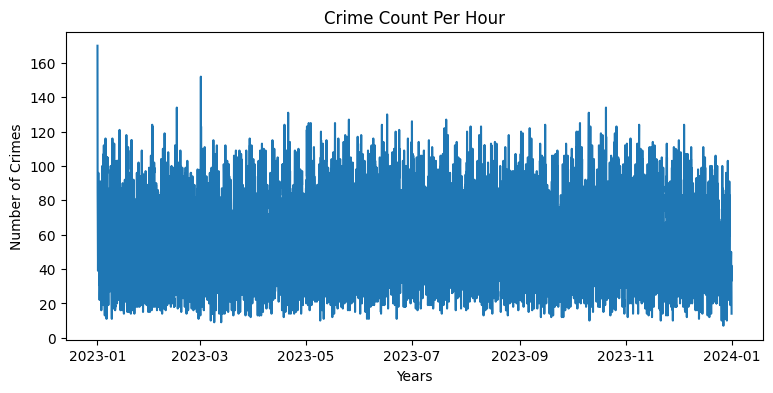

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(df_year.index, df_year['Crime Count'])
plt.title("Crime Count Per Hour")
plt.xlabel("Years")
plt.ylabel("Number of Crimes")

In [ ]:
df_year=df_year.reset_index()

In [ ]:
df_year

,date,Crime Count
0,2023-01-01 00:00:00,170
1,2023-01-01 01:00:00,88
2,2023-01-01 02:00:00,85
3,2023-01-01 03:00:00,79
4,2023-01-01 04:00:00,69
...,...,...
8755,2023-12-31 19:00:00,41
8756,2023-12-31 20:00:00,33
8757,2023-12-31 21:00:00,42
8758,2023-12-31 22:00:00,33


In [ ]:
df_year.to_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_2001_2023.csv', index=False)

In [ ]:
df_year=pd.read_csv('/content/drive/Othercomputers/My laptop/php/Crime_Database/New_York_2001_2023.csv')
df_year

,date,Crime Count
0,2023-01-01 00:00:00,170
1,2023-01-01 01:00:00,88
2,2023-01-01 02:00:00,85
3,2023-01-01 03:00:00,79
4,2023-01-01 04:00:00,69
...,...,...
8755,2023-12-31 19:00:00,41
8756,2023-12-31 20:00:00,33
8757,2023-12-31 21:00:00,42
8758,2023-12-31 22:00:00,33
